<img src="./logo_UNSAM.jpg" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# TS0: Primeros Pasos en la Simulación
#### Sofía Makkos


En esta primer entrega se diseñará un código capaz de admitir una serie de datos para simular señales senoidales. Los datos serán:

- Amplitud máxima de la senoidal (V): *vmax*
- Valor medio (V): *dc*
- Frecuencia (Hz): *ff*
- Fase (radianes): *ph*
- Cantidad de muestras digitalizadas por el ADC: *nn*
- Frecuencia de muestreo del ADC (Hz): *fs*

La función empleada, entonces, tendrá los parámetros:
tt, xx = mi_funcion_sen( vmax = 1, dc = 0, ff = 1, ph=0, nn = N, fs = fs)

Esta función seno se verá de manera:
\begin{equation}
xx=Vmax*sen(2*\pi*ff*nn/fs+ph)
\end{equation}

Importamos las librerías necesarias, inicializamos variables y definimos nuestra función principal:

In [ ]:
import numpy as np #Necesaria para la función np.sin()
import matplotlib.pyplot as plt # Necesaria para la creación de gráficos

#Definiciones
fs=1000 #Hz
N=1000 #muestras

#Funciones
def mi_funcion_sen( vmax = 1, dc = 0, ff = 1, ph=0, nn = N, fs = fs):
    tt=np.arange(0.0, N/fs, 1/fs)
    xx=vmax*np.sin(2*np.pi*ff*tt +ph)
    return(tt, xx)

A continuación, elegimos valores arbitrarios para la función seno, que se mantendrán constantes durante los siguientes códigos

In [6]:
vmax=2
dc=0
ph=0

Finalmente, utilizaremos nuestra función *mi_funcion_sen* para diferentes valores de *ff*

En primer lugar, emplearé un valor de 500Hz

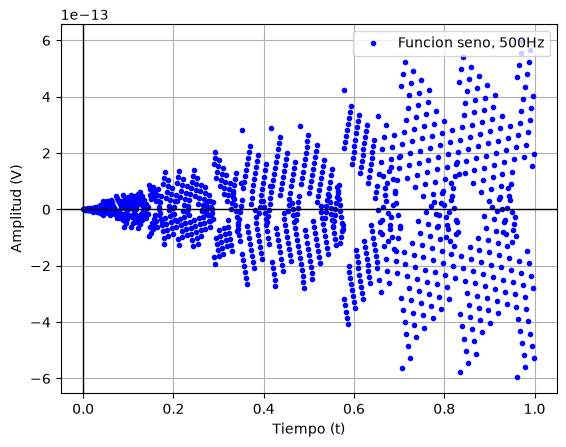

In [7]:
tt,xx=mi_funcion_sen(ff=500)
plt.plot(tt, xx, color="blue", linestyle=" ",marker=".",  label="Funcion seno, 500Hz")
plt.legend(loc="upper right")
plt.xlabel("Tiempo (t)")
plt.ylabel("Amplitud (V)")
plt.axhline(0, color="black", linewidth=1)
plt.axvline(0, color="black", linewidth=1)
plt.grid()
plt.show()

Este comportamiento se debe a que nos encontramos en la frecuencia de Nyquist *ffN*=*fs*/2=500Hz. Si tomamos la función senoidal, 

\begin{equation}
xx=Vmax*sen(2*\pi*500Hz*nn/1000Hz+ph)=2*sen(\pi*nn)
\end{equation}
Este función, por lo tanto, siempre será nula, debido a que sen($\pi$)=0. Aún así, si observamos la leyenda en la parte superior del gráfico, en cuanto al eje y, se lee "1e-13", lo cual indica que el gráfico representa órdenes muy chicos, cercanos al 0. Esto de debe a al error de cálculo del código en Python, que genera una nube alrededor del eje x. Idealmente, se debería representar una línea constante evaluada en el 0.

Por consiguiente, utilizaré *ff*=1001Hz

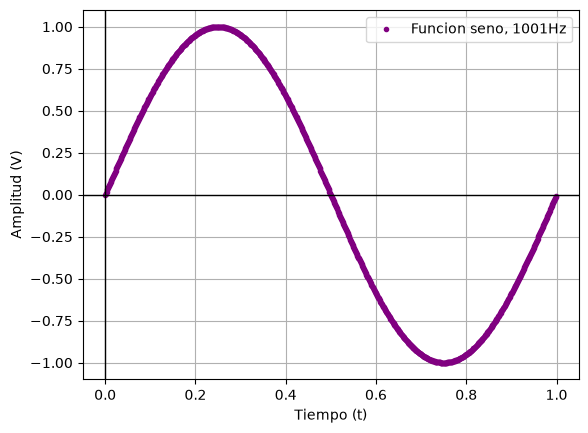

In [16]:
tt,xx=mi_funcion_sen(ff=1001)
plt.plot(tt, xx, color="purple", linestyle=" ",marker=".", label="Funcion seno, 1001Hz")
plt.legend(loc="upper right")
plt.xlabel("Tiempo (t)")
plt.ylabel("Amplitud (V)")
plt.axhline(0, color="black", linewidth=1)
plt.axvline(0, color="black", linewidth=1)
plt.grid()
plt.show()

Con esta nueva frecuencia, se observa un drástico cambio en el gráfico, el cual representa una sinusoidal común, aunque existe un detalle sutil. Si la comparamos con una función seno con *ff*=1Hz, se puede apreciar lo idéntico entre ellas: 

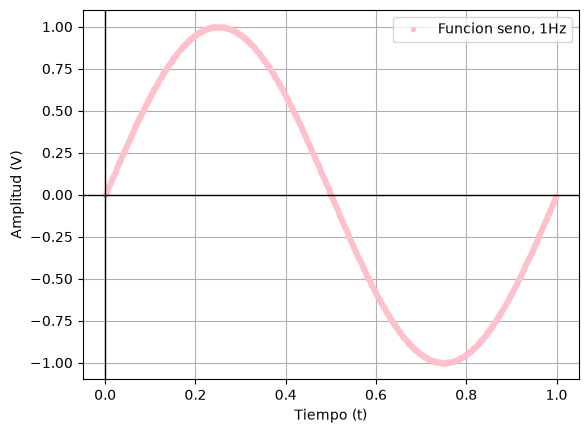

In [17]:
tt,xx=mi_funcion_sen(ff=1)
plt.plot(tt, xx, color="pink", linestyle=" ",marker=".", label="Funcion seno, 1Hz")
plt.legend(loc="upper right")
plt.xlabel("Tiempo (t)")
plt.ylabel("Amplitud (V)")
plt.axhline(0, color="black", linewidth=1)
plt.axvline(0, color="black", linewidth=1)
plt.grid()
plt.show()

Consecuentemente, podemos determinar que debido a que *fs*=1000Hz, a partir de la particularidad periódica de la función, podemos indicar que se vió completado un ciclo completo, dando a mostrar que el comportamiento con *ff*=1001Hz es idéntico al *ff*=1Hz

De la misma manera se puede hablar del caso de *ff*=2001Hz, en el que ya se habrán completado dos ciclos enteros:

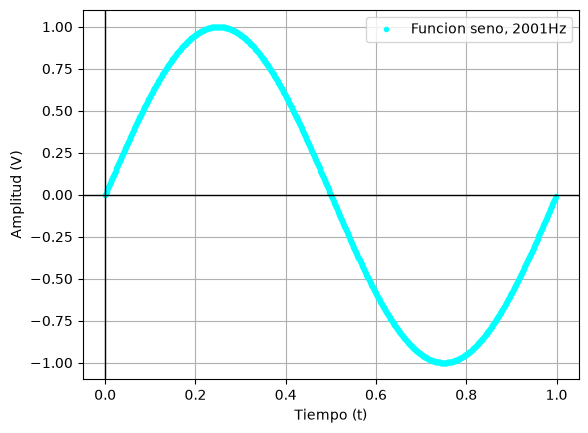

In [18]:
tt,xx=mi_funcion_sen(ff=2001)
plt.plot(tt, xx, color="cyan", linestyle=" ",marker=".", label="Funcion seno, 2001Hz")
plt.legend(loc="upper right")
plt.xlabel("Tiempo (t)")
plt.ylabel("Amplitud (V)")
plt.axhline(0, color="black", linewidth=1)
plt.axvline(0, color="black", linewidth=1)
plt.grid()
plt.show()

Finalmente, representamos la función sinusoide con  *ff*=2001Hz:

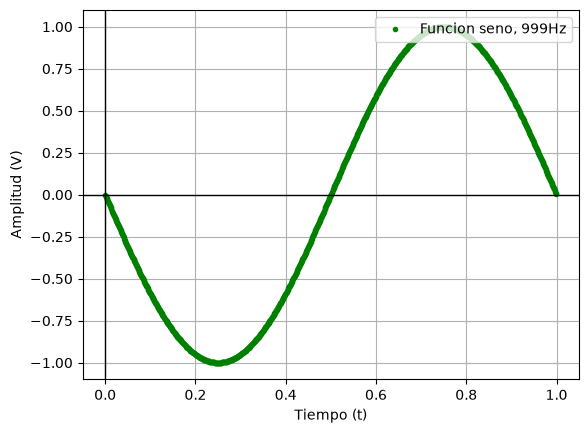

In [13]:
tt,xx=mi_funcion_sen(ff=999)
plt.plot(tt, xx, color="green", linestyle=" ",marker=".", label="Funcion seno, 999Hz")
plt.legend(loc="upper right")
plt.xlabel("Tiempo (t)")
plt.ylabel("Amplitud (V)")
plt.axhline(0, color="black", linewidth=1)
plt.axvline(0, color="black", linewidth=1)
plt.grid()
plt.show()

Nuevamente, nos encontramos con una sinusoidal "común". Sin embargo, comparando este gráfico con los anteriore, es evidente el cambio de fase. Esto ocurrió no por cambiar el valor de *ph*, sino por el salto en la frecuencia, el cual es mínimo. 

Por lo tanto, hace falta analizar un detalle. Retomando en que disponemos de *fs*=1000Hz, la frecuencia *ff*=999 la podemos considerar equivalente a *ff*=-1Hz:

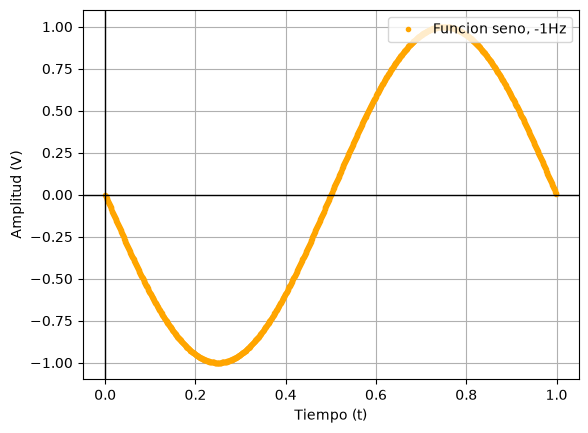

In [22]:
tt,xx=mi_funcion_sen(ff=-1)
plt.plot(tt, xx, color="orange", linestyle=" ",marker=".", label="Funcion seno, -1Hz")
plt.legend(loc="upper right")
plt.xlabel("Tiempo (t)")
plt.ylabel("Amplitud (V)")
plt.axhline(0, color="black", linewidth=1)
plt.axvline(0, color="black", linewidth=1)
plt.grid()
plt.show()

Es así, que se vuelve a observar este fenómeno periódico en relación a la *fs* elegida.